# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [1]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [2]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


2026-04-23 14:01:18.595369: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [3]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 4. Load the Data


In [4]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt
    # 2. Load y_train from train/y_train.txt
    # 3. Load X_test from test/X_test.txt
    # 4. Load y_test from test/y_test.txt
    # 5. Convert the labels to zero-based class indices by subtracting 1

    root_dir = pathlib.Path(root_dir)
    X_train = np.loadtxt(root_dir / "train" / "X_train.txt", dtype=np.float32)
    y_train = np.loadtxt(root_dir / "train" / "y_train.txt", dtype=np.int32) - 1
    X_test  = np.loadtxt(root_dir / "test"  / "X_test.txt",  dtype=np.float32)
    y_test  = np.loadtxt(root_dir / "test"  / "y_test.txt",  dtype=np.int32) - 1
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO: define num_features and num_classes
num_features = X_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)
print("num_features:", num_features)
print("num_classes :", num_classes)


X_train shape: (7352, 561)
X_test  shape: (2947, 561)
num_features: 561
num_classes : 6


## 5. Quick Inspection


In [5]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.

label_counts = pd.Series(y_train).value_counts().sort_index()

dataset_summary = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name": class_names,
    "Training Samples": label_counts.values,
})

dataset_summary


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [6]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64,  activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [7]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/40
92/92 [==============================] - 1s 4ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 3ms/step - loss: 0.1638 - accuracy: 0.9374 - val_loss: 0.1399 - val_accuracy: 0.9375
Epoch 3/40
92/92 [==============================] - 0s 3ms/step - loss: 0.1152 - accuracy: 0.9568 - val_loss: 0.2632 - val_accuracy: 0.9123
Epoch 4/40
92/92 [==============================] - 0s 3ms/step - loss: 0.0907 - accuracy: 0.9633 - val_loss: 0.1618 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 0s 3ms/step - loss: 0.0905 - accuracy: 0.9646 - val_loss: 0.2719 - val_accuracy: 0.9205
Epoch 6/40
92/92 [==============================] - 0s 3ms/step - loss: 0.0713 - accuracy: 0.9719 - val_loss: 0.2238 - val_accuracy: 0.9313
Epoch 7/40
92/92 [==============================] - 0s 3ms/step - loss: 0.0615 - accuracy: 0.9764 - val_loss: 0.1368 - val_accuracy: 0.9443
Epoch 8/40
92/92 [==

### Training Curves


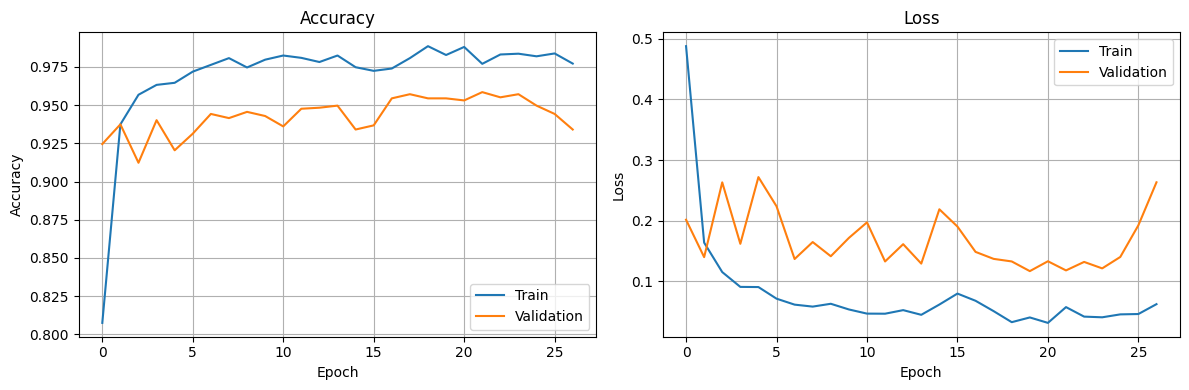

In [8]:
# TODO:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["accuracy"], label="Train")
axes[0].plot(history_df["val_accuracy"], label="Validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(history_df["loss"], label="Train")
axes[1].plot(history_df["val_loss"], label="Validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Loss")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Evaluate the Baseline Keras Model


Baseline Keras Test Accuracy: 0.9362

                    precision    recall  f1-score   support

           WALKING     0.9108    0.9879    0.9478       496
  WALKING_UPSTAIRS     0.9477    0.8854    0.9155       471
WALKING_DOWNSTAIRS     0.9562    0.9357    0.9458       420
           SITTING     0.9596    0.8697    0.9124       491
          STANDING     0.8639    0.9662    0.9122       532
            LAYING     1.0000    0.9646    0.9820       537

          accuracy                         0.9362      2947
         macro avg     0.9397    0.9349    0.9359      2947
      weighted avg     0.9391    0.9362    0.9362      2947



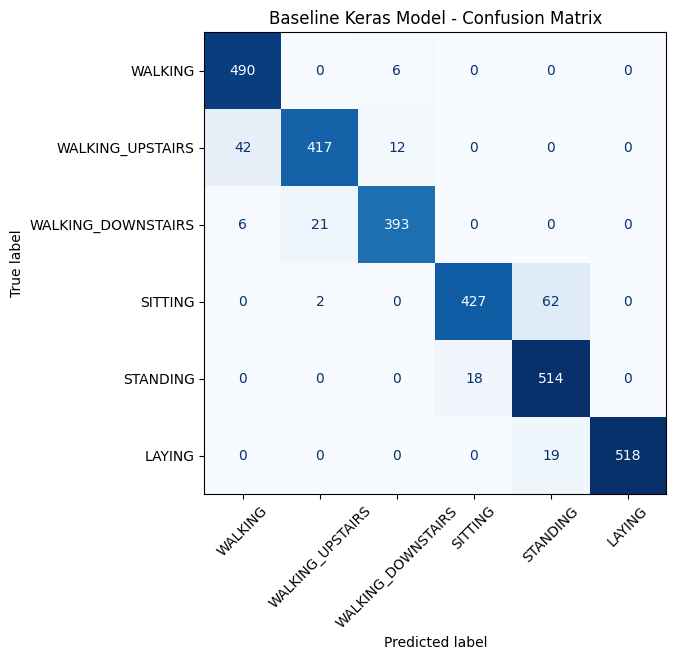

In [9]:
# TODO:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

baseline_probs = baseline_model.predict(X_test, verbose=0)
baseline_preds = np.argmax(baseline_probs, axis=1)
baseline_acc = accuracy_score(y_test, baseline_preds)

print(f"Baseline Keras Test Accuracy: {baseline_acc:.4f}\n")
print(classification_report(y_test, baseline_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, baseline_preds),
    display_labels=class_names,
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Baseline Keras Model - Confusion Matrix")
plt.show()


## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [10]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    # TODO:
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]

    for i in range(min(300, len(X_train))):
        yield [X_train[i:i+1].astype(np.float32)]

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.
        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # If the output is quantized, dequantize it back to float32.
        if output_details["dtype"] in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO: return the converted FP32 TensorFlow Lite model
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization and return the converted model.
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    # Return the converted model
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()


## 9. Post-Training Quantization (PTQ)


In [11]:
# TODO:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.

fp32_tflite    = convert_to_tflite_fp32(baseline_model)
dynrange_tflite = convert_to_tflite_dynamic_range(baseline_model)
fp16_tflite    = convert_to_tflite_float16(baseline_model)
int8_tflite    = convert_to_tflite_int8(baseline_model)

fp32_size_kb     = save_binary_model(fp32_tflite,     "baseline_fp32.tflite")
dynrange_size_kb = save_binary_model(dynrange_tflite, "baseline_dynrange.tflite")
fp16_size_kb     = save_binary_model(fp16_tflite,     "baseline_fp16.tflite")
int8_size_kb     = save_binary_model(int8_tflite,     "baseline_int8.tflite")

fp32_acc,     fp32_preds     = evaluate_tflite_model(fp32_tflite,     X_test, y_test)
dynrange_acc, dynrange_preds = evaluate_tflite_model(dynrange_tflite, X_test, y_test)
fp16_acc,     fp16_preds     = evaluate_tflite_model(fp16_tflite,     X_test, y_test)
int8_acc,     int8_preds     = evaluate_tflite_model(int8_tflite,     X_test, y_test)

print(f"FP32         acc={fp32_acc:.4f}  size={fp32_size_kb:.2f} KB")
print(f"Dynamic Rng  acc={dynrange_acc:.4f}  size={dynrange_size_kb:.2f} KB")
print(f"Float16      acc={fp16_acc:.4f}  size={fp16_size_kb:.2f} KB")
print(f"Int8         acc={int8_acc:.4f}  size={int8_size_kb:.2f} KB")


INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmpmy1bcyza/assets


INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmpmy1bcyza/assets
2026-04-23 14:01:35.160394: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 14:01:35.160414: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 14:01:35.160755: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmpmy1bcyza
2026-04-23 14:01:35.162009: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 14:01:35.162023: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmpmy1bcyza
2026-04-23 14:01:35.164407: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-23 14:01:35.165387: I tensorflow/cc/saved_model/load

INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp6h3h6bzj/assets


INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp6h3h6bzj/assets
2026-04-23 14:01:35.977617: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 14:01:35.977634: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 14:01:35.977818: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp6h3h6bzj
2026-04-23 14:01:35.979005: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 14:01:35.979014: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp6h3h6bzj
2026-04-23 14:01:35.982112: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 14:01:36.024090: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp2ptbq50x/assets


INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp2ptbq50x/assets
2026-04-23 14:01:36.697389: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 14:01:36.697404: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 14:01:36.697577: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp2ptbq50x
2026-04-23 14:01:36.698677: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 14:01:36.698687: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmp2ptbq50x
2026-04-23 14:01:36.701809: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 14:01:36.744137: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmpdl3z1etj/assets


INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmpdl3z1etj/assets
/Users/leoxie/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-23 14:01:37.656575: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 14:01:37.656593: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 14:01:37.656767: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmpdl3z1etj
2026-04-23 14:01:37.657716: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 14:01:37.657725: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/ds/vqtbdcsn7xlbn0

FP32         acc=0.9362  size=726.72 KB
Dynamic Rng  acc=0.9365  size=186.11 KB
Float16      acc=0.9362  size=365.71 KB
Int8         acc=0.9359  size=185.34 KB


## 10. PTQ Comparison: Accuracy and Model Size


In [12]:
# TODO:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)

ptq_results = pd.DataFrame([
    ["Baseline", "FP32",          fp32_acc,     fp32_size_kb],
    ["Baseline", "Dynamic Range", dynrange_acc, dynrange_size_kb],
    ["Baseline", "Float16",       fp16_acc,     fp16_size_kb],
    ["Baseline", "Int8",          int8_acc,     int8_size_kb],
], columns=["Model Family", "Format", "Test Accuracy", "Model Size (KB)"])

ptq_results


,Model Family,Format,Test Accuracy,Model Size (KB)
0,Baseline,FP32,0.936206,726.718750
1,Baseline,Dynamic Range,0.936546,186.109375
2,Baseline,Float16,0.936206,365.710938
3,Baseline,Int8,0.935867,185.335938


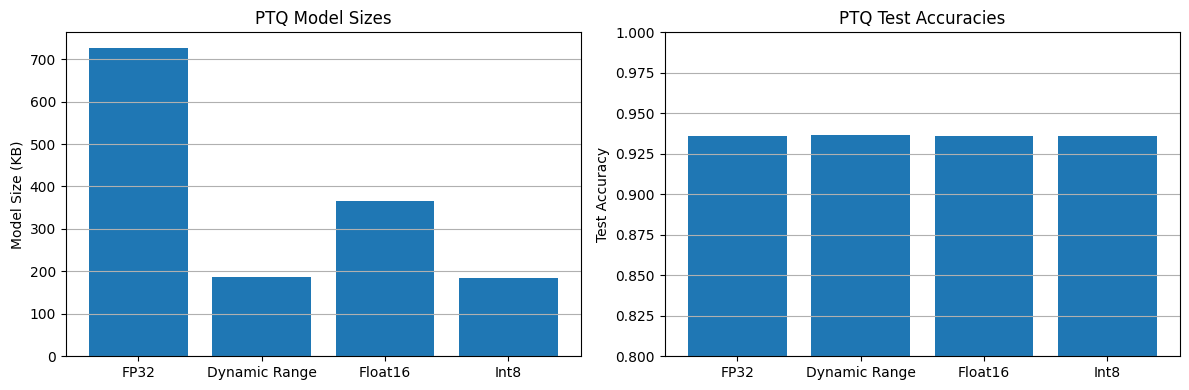

In [13]:
# TODO:
# Create one bar plot for model size and another for test accuracy.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(ptq_results["Format"], ptq_results["Model Size (KB)"])
axes[0].set_ylabel("Model Size (KB)")
axes[0].set_title("PTQ Model Sizes")
axes[0].grid(axis="y")

axes[1].bar(ptq_results["Format"], ptq_results["Test Accuracy"])
axes[1].set_ylim(0.80, 1.00)
axes[1].set_ylabel("Test Accuracy")
axes[1].set_title("PTQ Test Accuracies")
axes[1].grid(axis="y")

plt.tight_layout()
plt.show()


### Confusion Matrix for the PTQ Int8 Model


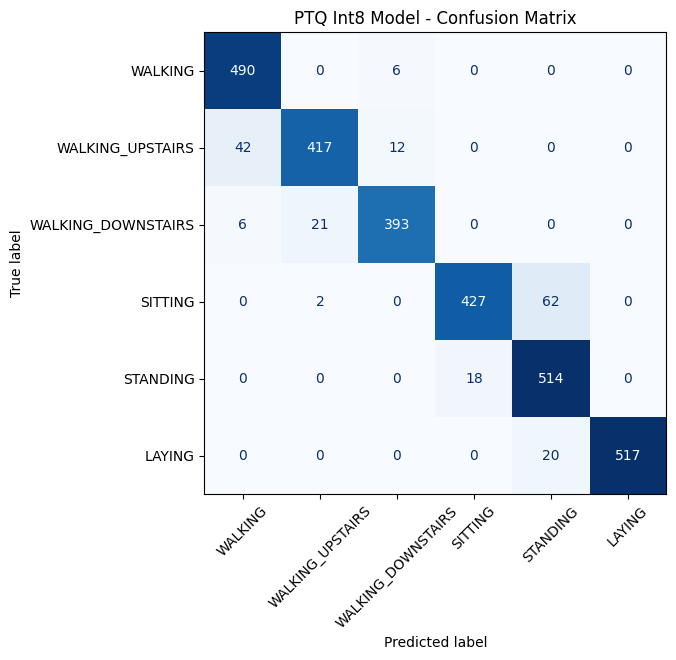

                    precision    recall  f1-score   support

           WALKING     0.9108    0.9879    0.9478       496
  WALKING_UPSTAIRS     0.9477    0.8854    0.9155       471
WALKING_DOWNSTAIRS     0.9562    0.9357    0.9458       420
           SITTING     0.9596    0.8697    0.9124       491
          STANDING     0.8624    0.9662    0.9113       532
            LAYING     1.0000    0.9628    0.9810       537

          accuracy                         0.9359      2947
         macro avg     0.9394    0.9346    0.9356      2947
      weighted avg     0.9388    0.9359    0.9359      2947



In [14]:
# TODO:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, int8_preds),
    display_labels=class_names,
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("PTQ Int8 Model - Confusion Matrix")
plt.show()

print(classification_report(y_test, int8_preds, target_names=class_names, digits=4))


## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [15]:
# TODO:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

quantize_model = tfmot.quantization.keras.quantize_model
qat_model = quantize_model(baseline_model)

qat_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
qat_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 quantize_layer (QuantizeLa  (None, 561)               3         
 yer)                                                            
                                                                 
 quant_dense (QuantizeWrapp  (None, 256)               143877    
 erV2)                                                           
                                                                 
 quant_dense_1 (QuantizeWra  (None, 128)               32901     
 pperV2)                                                         
                                                                 
 quant_dense_2 (QuantizeWra  (None, 64)                8261      
 pperV2)                                                         
                                                                 
 quant_dense_3 (QuantizeWra  (None, 6)                 3

### Fine-Tune the QAT Model


In [16]:
# TODO:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

qat_history = qat_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64,
    verbose=1,
)


Epoch 1/8
92/92 [==============================] - 2s 8ms/step - loss: 0.0310 - accuracy: 0.9896 - val_loss: 0.1236 - val_accuracy: 0.9579
Epoch 2/8
92/92 [==============================] - 0s 5ms/step - loss: 0.0258 - accuracy: 0.9910 - val_loss: 0.1282 - val_accuracy: 0.9572
Epoch 3/8
92/92 [==============================] - 0s 4ms/step - loss: 0.0247 - accuracy: 0.9923 - val_loss: 0.1263 - val_accuracy: 0.9579
Epoch 4/8
92/92 [==============================] - 0s 4ms/step - loss: 0.0227 - accuracy: 0.9918 - val_loss: 0.1252 - val_accuracy: 0.9585
Epoch 5/8
92/92 [==============================] - 0s 4ms/step - loss: 0.0211 - accuracy: 0.9935 - val_loss: 0.1447 - val_accuracy: 0.9551
Epoch 6/8
92/92 [==============================] - 0s 4ms/step - loss: 0.0228 - accuracy: 0.9906 - val_loss: 0.1457 - val_accuracy: 0.9565
Epoch 7/8
92/92 [==============================] - 1s 6ms/step - loss: 0.0205 - accuracy: 0.9922 - val_loss: 0.1308 - val_accuracy: 0.9592
Epoch 8/8
92/92 [==========

### Evaluate the QAT Keras Model


In [17]:
# TODO:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

qat_probs = qat_model.predict(X_test, verbose=0)
qat_preds = np.argmax(qat_probs, axis=1)
qat_keras_acc = accuracy_score(y_test, qat_preds)

print(f"QAT Keras Test Accuracy: {qat_keras_acc:.4f}\n")
print(classification_report(y_test, qat_preds, target_names=class_names, digits=4))


QAT Keras Test Accuracy: 0.9359

                    precision    recall  f1-score   support

           WALKING     0.9295    0.9839    0.9559       496
  WALKING_UPSTAIRS     0.9270    0.9172    0.9221       471
WALKING_DOWNSTAIRS     0.9625    0.9167    0.9390       420
           SITTING     0.9574    0.8697    0.9114       491
          STANDING     0.8591    0.9624    0.9078       532
            LAYING     1.0000    0.9572    0.9781       537

          accuracy                         0.9359      2947
         macro avg     0.9393    0.9345    0.9357      2947
      weighted avg     0.9386    0.9359    0.9361      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [18]:
# TODO:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

qat_int8_tflite = convert_to_tflite_int8(qat_model)
qat_int8_size_kb = save_binary_model(qat_int8_tflite, "qat_int8.tflite")
qat_int8_acc, qat_int8_preds = evaluate_tflite_model(qat_int8_tflite, X_test, y_test)

print(f"QAT Int8 Test Accuracy: {qat_int8_acc:.4f}")
print(f"QAT Int8 Size (KB):     {qat_int8_size_kb:.2f}")


INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmpvszhdbqo/assets


INFO:tensorflow:Assets written to: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmpvszhdbqo/assets
/Users/leoxie/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-23 14:01:48.982480: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 14:01:48.982511: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 14:01:48.982793: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/ds/vqtbdcsn7xlbn06mfwj3gzs40000gp/T/tmpvszhdbqo
2026-04-23 14:01:48.988147: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 14:01:48.988177: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/ds/vqtbdcsn7xlbn0

QAT Int8 Test Accuracy: 0.9359
QAT Int8 Size (KB):     185.70


## 12. PTQ Int8 vs QAT Int8


In [19]:
# TODO:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

int8_comparison = pd.DataFrame([
    ["PTQ Int8", int8_acc,     int8_size_kb],
    ["QAT Int8", qat_int8_acc, qat_int8_size_kb],
], columns=["Model", "Test Accuracy", "Model Size (KB)"])

int8_comparison


,Model,Test Accuracy,Model Size (KB)
0,PTQ Int8,0.935867,185.335938
1,QAT Int8,0.935867,185.695312


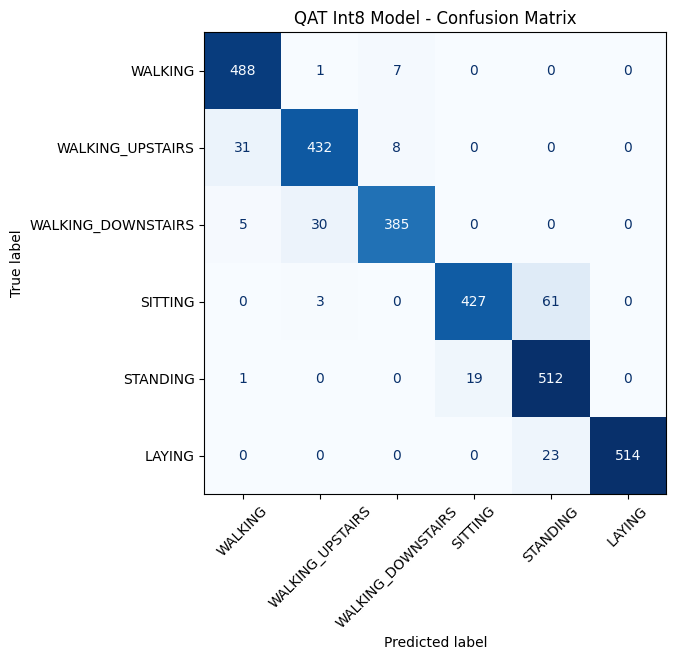

In [20]:
# TODO:
# Plot the confusion matrix for the QAT int8 model.

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, qat_int8_preds),
    display_labels=class_names,
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("QAT Int8 Model - Confusion Matrix")
plt.show()


## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size? 

**The INT8 QAT and PTQ produced the smallest size.**


2. Which quantization method gave the best accuracy among the TensorFlow Lite models? 

**Everything is quite close, but Dynamic Range gave the best accuracy for my runs.**
3. Did QAT improve the final int8 model compared with PTQ int8? 

**For my numbers and runs, QAT did not show a significant improvement for the final int8 model over PTQ int8. In fact, it even slightly increased the size of the model. I think if for this dataset, the PQT int8 accuracy drops significantly, QAT would help, but that is not the case here.**

4. Why is this dataset a good fit for a DNN-based TinyML workflow?

**It has a small, fixed input with all of them already a compact vector, so there's no need for CNN/RNN front ends to process the images into flattened vectors. It also has a small model footprint, which helps putting it on small edge devices, perfect application for TinyML.**

5. If you were deploying this model on a resource-constrained device, which version would you choose and why? 

**For this particular model, I would deploy the PTQ int8 model, because it has the same accuracy as QAT int8 (0.935867 = 0.935867) and slightly smaller (185.335938 < 185.695312).**


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
